# Task 01: House Price Prediction using Linear Regression
**Organization:** SkillCraft Technology  
**Role:** Machine Learning Intern  
**Objective:** Build a regression model that predicts house prices in Indian Rupees (₹) using square footage (`area`), number of bedrooms, and number of bathrooms.

---
## Notebook Table of Contents
1. **Data Loading & Inspection**
2. **Exploratory Data Analysis (EDA) & Data Visualizations**
3. **Data Preprocessing & Outlier Handling**
4. **Feature Engineering (Spatial Ratio)**
5. **Feature Scaling & Train-Test Split**
6. **Model Building & Training**
7. **Model Evaluation & Performance Metrics**
8. **Prediction on New Custom Data**
9. **Export Model Parameters for Web Site Integration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

# Set aesthetic styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Data Loading & Inspection
We load the raw housing dataset (`Housing.csv`) and inspect its structural shapes, column headers, data types, and check for missing values to prepare for data cleaning.

In [2]:
# Loading the dataset
df = pd.read_csv('Housing.csv')

# Inspect dimensions
print(f"Dataset shape: {df.shape}")
print("\n--- First 5 rows of the dataset ---")
display(df.head())

print("\n--- Dataset Info (Data types & Null status) ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

Dataset shape: (545, 13)

--- First 5 rows of the dataset ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



--- Dataset Info (Data types & Null status) ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

--- Missing Values Count ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad      

## 2. Exploratory Data Analysis (EDA) & Data Visualizations
Before preparing the model, we inspect the univariate distributions and bivariate relationships of the target variable (`price`) and features of interest: `area` (square footage), `bedrooms`, and `bathrooms`.

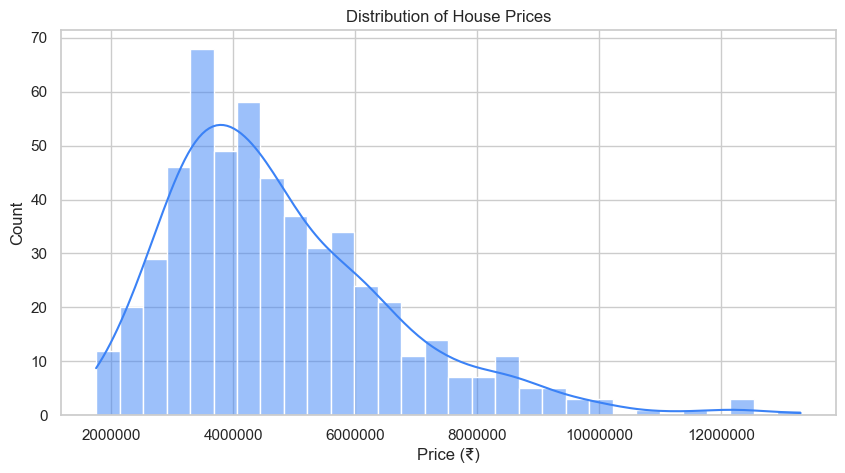

In [3]:
# Target price distribution histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='#3b82f6', bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

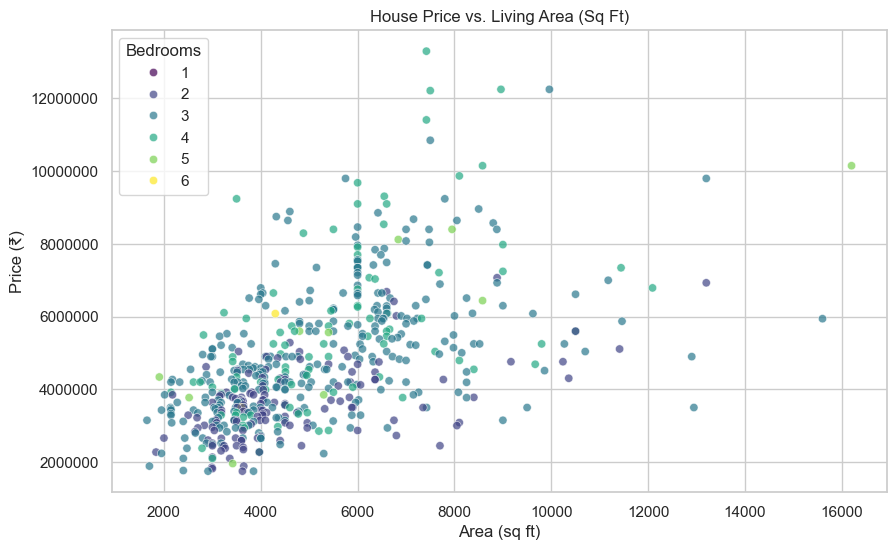

In [4]:
# Area vs Price scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='price', hue='bedrooms', palette='viridis', alpha=0.7)
plt.title('House Price vs. Living Area (Sq Ft)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Bedrooms')
plt.show()

D:\Temp\ipykernel_5172\2559752616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='bedrooms', y='price', palette='Blues')
D:\Temp\ipykernel_5172\2559752616.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='bathrooms', y='price', palette='Greens')


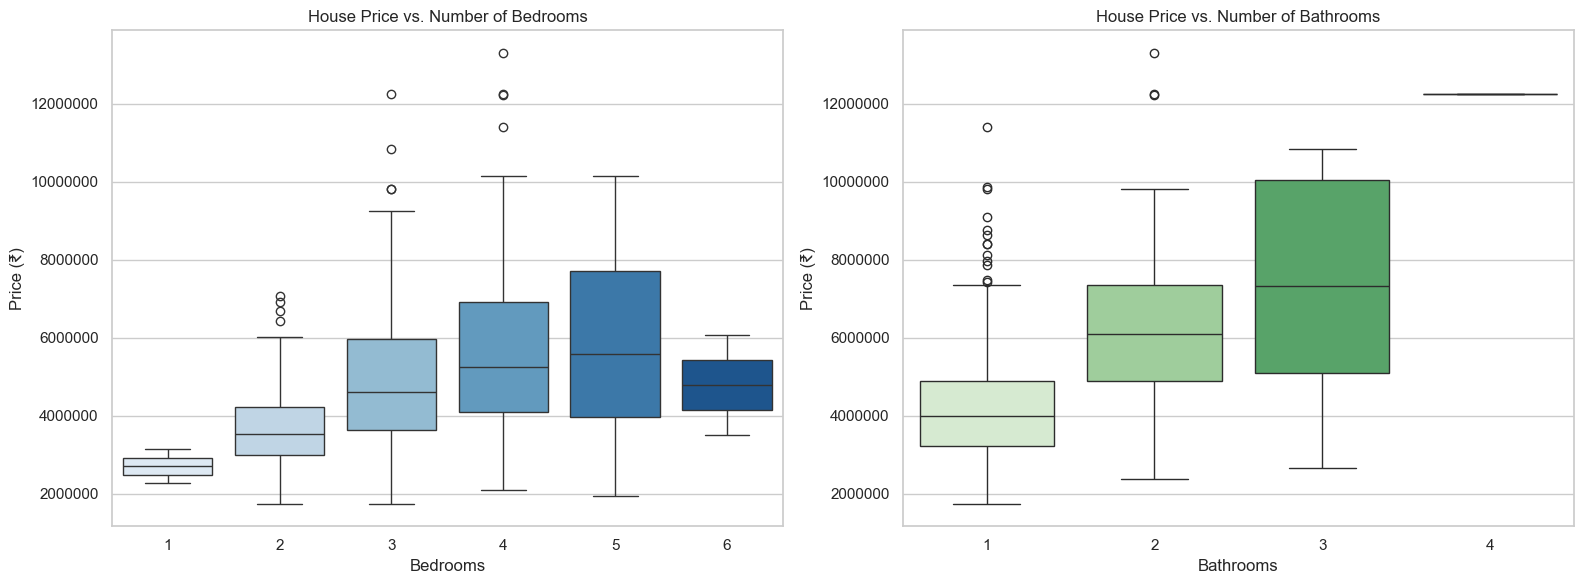

In [5]:
# Bedrooms and Bathrooms vs Price boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df, x='bedrooms', y='price', palette='Blues')
axes[0].set_title('House Price vs. Number of Bedrooms')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Price (₹)')
axes[0].ticklabel_format(style='plain', axis='y')

sns.boxplot(ax=axes[1], data=df, x='bathrooms', y='price', palette='Greens')
axes[1].set_title('House Price vs. Number of Bathrooms')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Price (₹)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Outlier Handling
Linear regression models are highly sensitive to extreme outliers because the squared error loss function penalizes large deviations disproportionately. We check for outlier distributions and filter them out using the Interquartile Range (IQR) method.

In [6]:
# Check outlier counts by column using IQR
features = ['area', 'bedrooms', 'bathrooms']
cleaned_df = df.copy()

for col in features:
    q1 = cleaned_df[col].quantile(0.25)
    q3 = cleaned_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_cutoff = q1 - 1.5 * iqr
    upper_cutoff = q3 + 1.5 * iqr
    
    outliers = cleaned_df[(cleaned_df[col] < lower_cutoff) | (cleaned_df[col] > upper_cutoff)]
    print(f"Feature '{col}': found {len(outliers)} outliers (Bounds: {lower_cutoff:.1f} to {upper_cutoff:.1f})")
    
    # Remove outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_cutoff) & (cleaned_df[col] <= upper_cutoff)]

print(f"\nTotal rows before outlier cleaning: {len(df)}")
print(f"Total rows after outlier cleaning: {len(cleaned_df)}")
print(f"Total outliers removed: {len(df) - len(cleaned_df)}")

Feature 'area': found 12 outliers (Bounds: -540.0 to 10500.0)
Feature 'bedrooms': found 11 outliers (Bounds: 0.5 to 4.5)
Feature 'bathrooms': found 1 outliers (Bounds: -0.5 to 3.5)

Total rows before outlier cleaning: 545
Total rows after outlier cleaning: 521
Total outliers removed: 24


## 4. Feature Engineering (Spatial Ratio)
We engineer a custom density ratio feature: `area_per_bedroom` (the average square footage allocated per bedroom). This captures layout efficiency and layout spaciousness. We add a small constant `0.1` to the denominator to prevent division-by-zero errors.

In [7]:
# Add spatial ratio engineered feature
cleaned_df['area_per_bedroom'] = cleaned_df['area'] / (cleaned_df['bedrooms'] + 0.1)
print("Engineered feature 'area_per_bedroom' added successfully.")
display(cleaned_df[['area', 'bedrooms', 'area_per_bedroom']].head())

Engineered feature 'area_per_bedroom' added successfully.


,area,bedrooms,area_per_bedroom
0,7420,4,1809.756098
2,9960,3,3212.903226
3,7500,4,1829.268293
4,7420,4,1809.756098
5,7500,3,2419.354839


Let's analyze the correlation of all numerical features in our filtered dataset, including the engineered feature, using a Seaborn Heatmap.

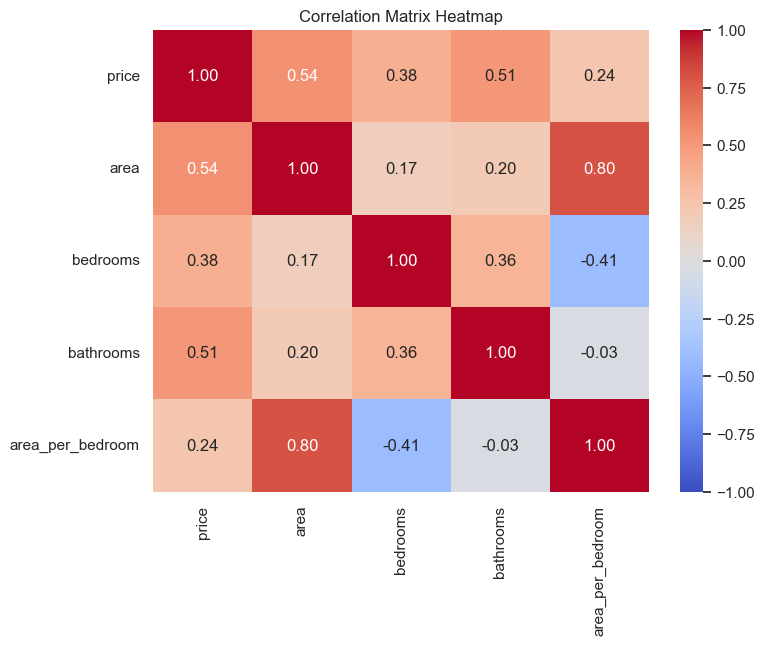

In [8]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = cleaned_df[['price', 'area', 'bedrooms', 'bathrooms', 'area_per_bedroom']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

## 5. Feature Scaling & Train-Test Split
We split the inputs `X` and target variable `y`. We perform an 80-20 train-test split for stable validation. Then, because the features are on widely different scales (e.g. `area` ranges in thousands, while room counts range from 1 to 4), we apply `StandardScaler` to scale features to Z-score Z-mean and Z-scale. This ensures standard convergence and interpretable coefficients.

In [9]:
# Define features and target
X = cleaned_df[['area', 'bedrooms', 'bathrooms', 'area_per_bedroom']]
y = cleaned_df['price']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (416, 4)
Testing set shape: (105, 4)


## 6. Model Building & Training
We fit a multivariate Scikit-Learn `LinearRegression` model to standard training features.

In [10]:
# Fit the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print(f"Model Intercept: ₹{lr_model.intercept_:,.2f}")
print("\nModel Coefficients:")
for idx, col in enumerate(X.columns):
    print(f" - {col}: {lr_model.coef_[idx]:+,.2f}")

Model Intercept: ₹4,641,252.40

Model Coefficients:
 - area: +1,578,374.80
 - bedrooms: -225,257.06
 - bathrooms: +618,029.70
 - area_per_bedroom: -891,650.81


### Multicollinearity & Coeff Interpretability Note
In our linear regression model, we notice that `bedrooms` and `area_per_bedroom` show negative coefficients. This indicates:
1. When keeping total living area constant, adding more bedrooms means individual room sizes shrink, which buyers value less (causing a negative slope on `bedrooms`).
2. There is a strong linear relationship (multicollinearity) between `area`, `bedrooms`, and `area_per_bedroom` which causes the regression coefficients to dynamically balance each other out during gradient minimization.

## 7. Model Evaluation & Performance Metrics
We test our regression model on the unseen test set and compute the required performance metrics:
- **Mean Absolute Error (MAE)**: Measures average absolute prediction error in Rupees.
- **Mean Squared Error (MSE)**: Measures average squared prediction errors, highlighting large errors.
- **Root Mean Squared Error (RMSE)**: The standard deviation of prediction errors in Rupees.
- **R-squared Score ($R^2$)**: The proportion of the variance in the target variable that is explainable by the model.

In [11]:
# Predict on test split
predictions = lr_model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): ₹1,180,967.16
Mean Squared Error (MSE): 2,457,196,879,839.07
Root Mean Squared Error (RMSE): ₹1,567,544.86
R-squared Score (R2): 0.4551


Let's visualize the fit of our model by plotting Actual Price vs. Predicted Price, along with the ideal $y = x$ perfect prediction line.

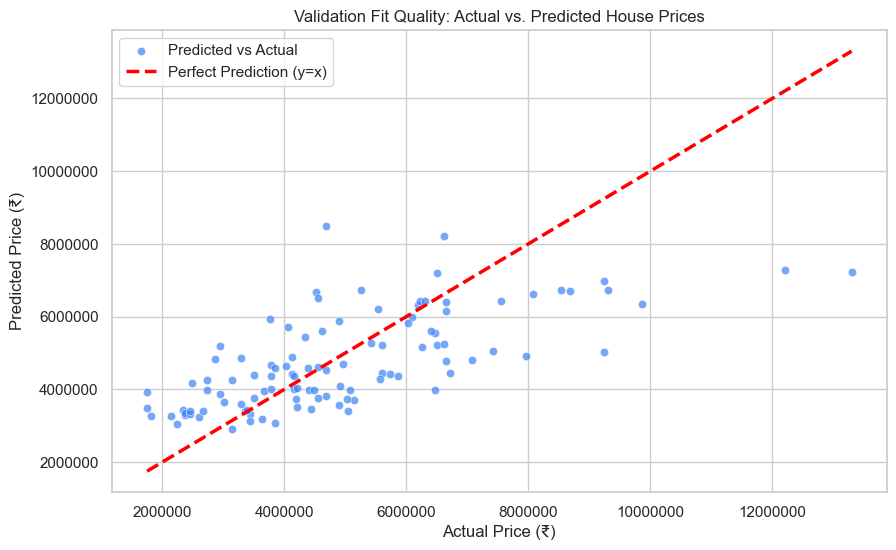

In [12]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, color='#3b82f6', alpha=0.7, label='Predicted vs Actual')
# Perfect prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='Perfect Prediction (y=x)')

plt.title('Validation Fit Quality: Actual vs. Predicted House Prices')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.show()

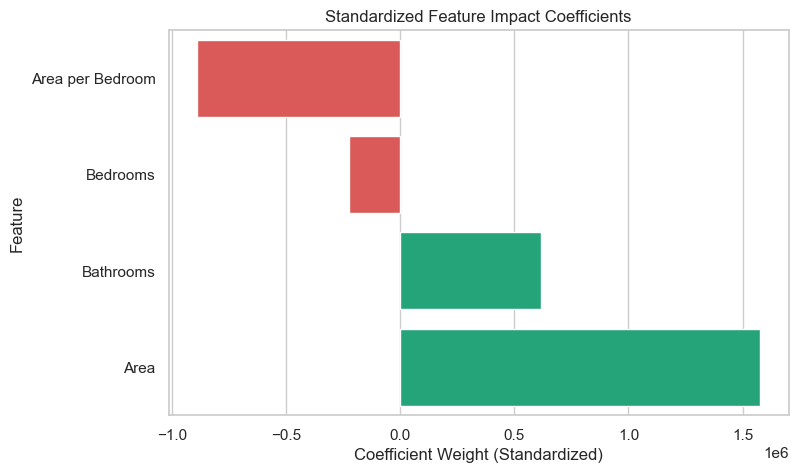

In [13]:
# Visualizing Feature Impact Coefficients
coef_df = pd.DataFrame({
    'Feature': ['Area', 'Bedrooms', 'Bathrooms', 'Area per Bedroom'],
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#ef4444' if c < 0 else '#10b981' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors, hue='Feature', legend=False)
plt.title('Standardized Feature Impact Coefficients')
plt.xlabel('Coefficient Weight (Standardized)')
plt.ylabel('Feature')
plt.show()

## 8. Prediction on New Custom Data
We build a helper function to predict the value of any custom property by taking raw inputs, scaling them with the trained scaler, and performing model inference.

In [14]:
def estimate_house_price(area_val, bedrooms_val, bathrooms_val):
    # Dynamic feature computation
    area_per_bed_val = area_val / (bedrooms_val + 0.1)
    
    # Input vector
    raw_inputs = np.array([[area_val, bedrooms_val, bathrooms_val, area_per_bed_val]])
    
    # Scale inputs
    scaled_inputs = scaler.transform(raw_inputs)
    
    # Inference prediction
    predicted_price = lr_model.predict(scaled_inputs)[0]
    
    # Restrict price from being negative
    final_price = max(0.0, predicted_price)
    
    print(f"--- House Valuation Estimate ---")
    print(f"Inputs: {area_val:,} sq ft | {bedrooms_val} beds | {bathrooms_val} baths")
    print(f"Spatial Density Ratio: {area_per_bed_val:.1f} sq ft per bedroom")
    print(f"Estimated Market Value: ₹{final_price:,.2f}")
    return final_price

# Example prediction
estimate_house_price(2200, 3, 2)

--- House Valuation Estimate ---
Inputs: 2,200 sq ft | 3 beds | 2 baths
Spatial Density Ratio: 709.7 sq ft per bedroom
Estimated Market Value: ₹4,422,074.06


C:\Users\impan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


4422074.057405645

## 9. Export Model Parameters for Web Site Integration
To make the React frontend site dynamic, we export the scaler Z-score stats and parameters to a JSON file.

In [15]:
# Save params to json for web client integration
export_data = {
    "features": list(X.columns),
    "mean": list(scaler.mean_),
    "scale": list(scaler.scale_),
    "coef": list(lr_model.coef_),
    "intercept": float(lr_model.intercept_),
    "mae": float(mae),
    "mse": float(mse),
    "rmse": float(rmse),
    "r2": float(r2),
    "dataset": cleaned_df[['price', 'area', 'bedrooms', 'bathrooms', 'area_per_bedroom']].to_dict(orient='records')
}

with open('model_params.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("model_params.json file created successfully.")

model_params.json file created successfully.
